<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20analysis/Psuedobulk_DifferentialGeneExpression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Differential gene expression using PyDEseq2

## Comparison: Hypoxia 2hrs vs Normoxia 6hpf

PyDEseq2 citation:

@article{muzellec2023pydeseq2,
  title={PyDESeq2: a python package for bulk RNA-seq differential expression analysis},
  author={Muzellec, Boris and Telenczuk, Maria and Cabeli, Vincent and Andreux, Mathieu},
  year={2023},
  doi = {10.1093/bioinformatics/btad547},
  journal={Bioinformatics},
}

and

https://github.com/scverse/PyDESeq2

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/your/path/'  #change dir to your project folder
save_path = '/your/path/Hypoxia2hrsVs6hpf/'

## Environment Setup

In [11]:
# print python version to screen
!python --version

# pip install software
!pip install -q scanpy
!pip install colab-xterm gdown
!pip -q install pydeseq2
!pip install adjusttext

# import python packages
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import warnings
import matplotlib.pyplot as plt


# set some ScanPy settings
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.settings.verbosity = 0

Python 3.12.13


In [4]:
adata_full = sc.read(('/your/path/scDataset.h5ad'))

In [6]:
adata = adata_full.copy()

In [7]:
#filter

OfInterst = ['Normoxia_6hpf_WT', 'Hypoxia_2hrs_WT']
sliceindex = adata.obs['Group'].isin(OfInterst)
adata = adata[sliceindex].copy()
adata

AnnData object with n_obs × n_vars = 29327 × 32102
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'Group', 'Condition', 'Genotype', 'total_counts', 'n_genes_by_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'batch', 'total_counts_mt', 'pct_counts_mt', 'percent_mt2', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    var: 'gene_id', 'genome', 'n_cells', 'mito', 'ribo'
    uns: 'Condition_colors', 'Genotype_colors', 'Group_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'majority_voting_colors', 'n_sig_PCs', 'n

In [8]:
# taken from https://github.com/wagnerde/scTools-py/blob/master/scTools_dew.py

def plot_stacked_barplot(labels_A,
                         labels_B,
                         normalize='index',
                         fig_width=4,
                         fig_height=4):

    # Cross-tabulate the two sets of labels
    crstb = pd.crosstab(labels_A, labels_B, normalize=normalize)

    # Plot stacked bars
    crstb.plot.bar(stacked=True, width=0.8, figsize=(fig_width, fig_height))
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.ylim([0,1])
    plt.ylabel('Proportion')
    plt.grid(False)
    plt.show()

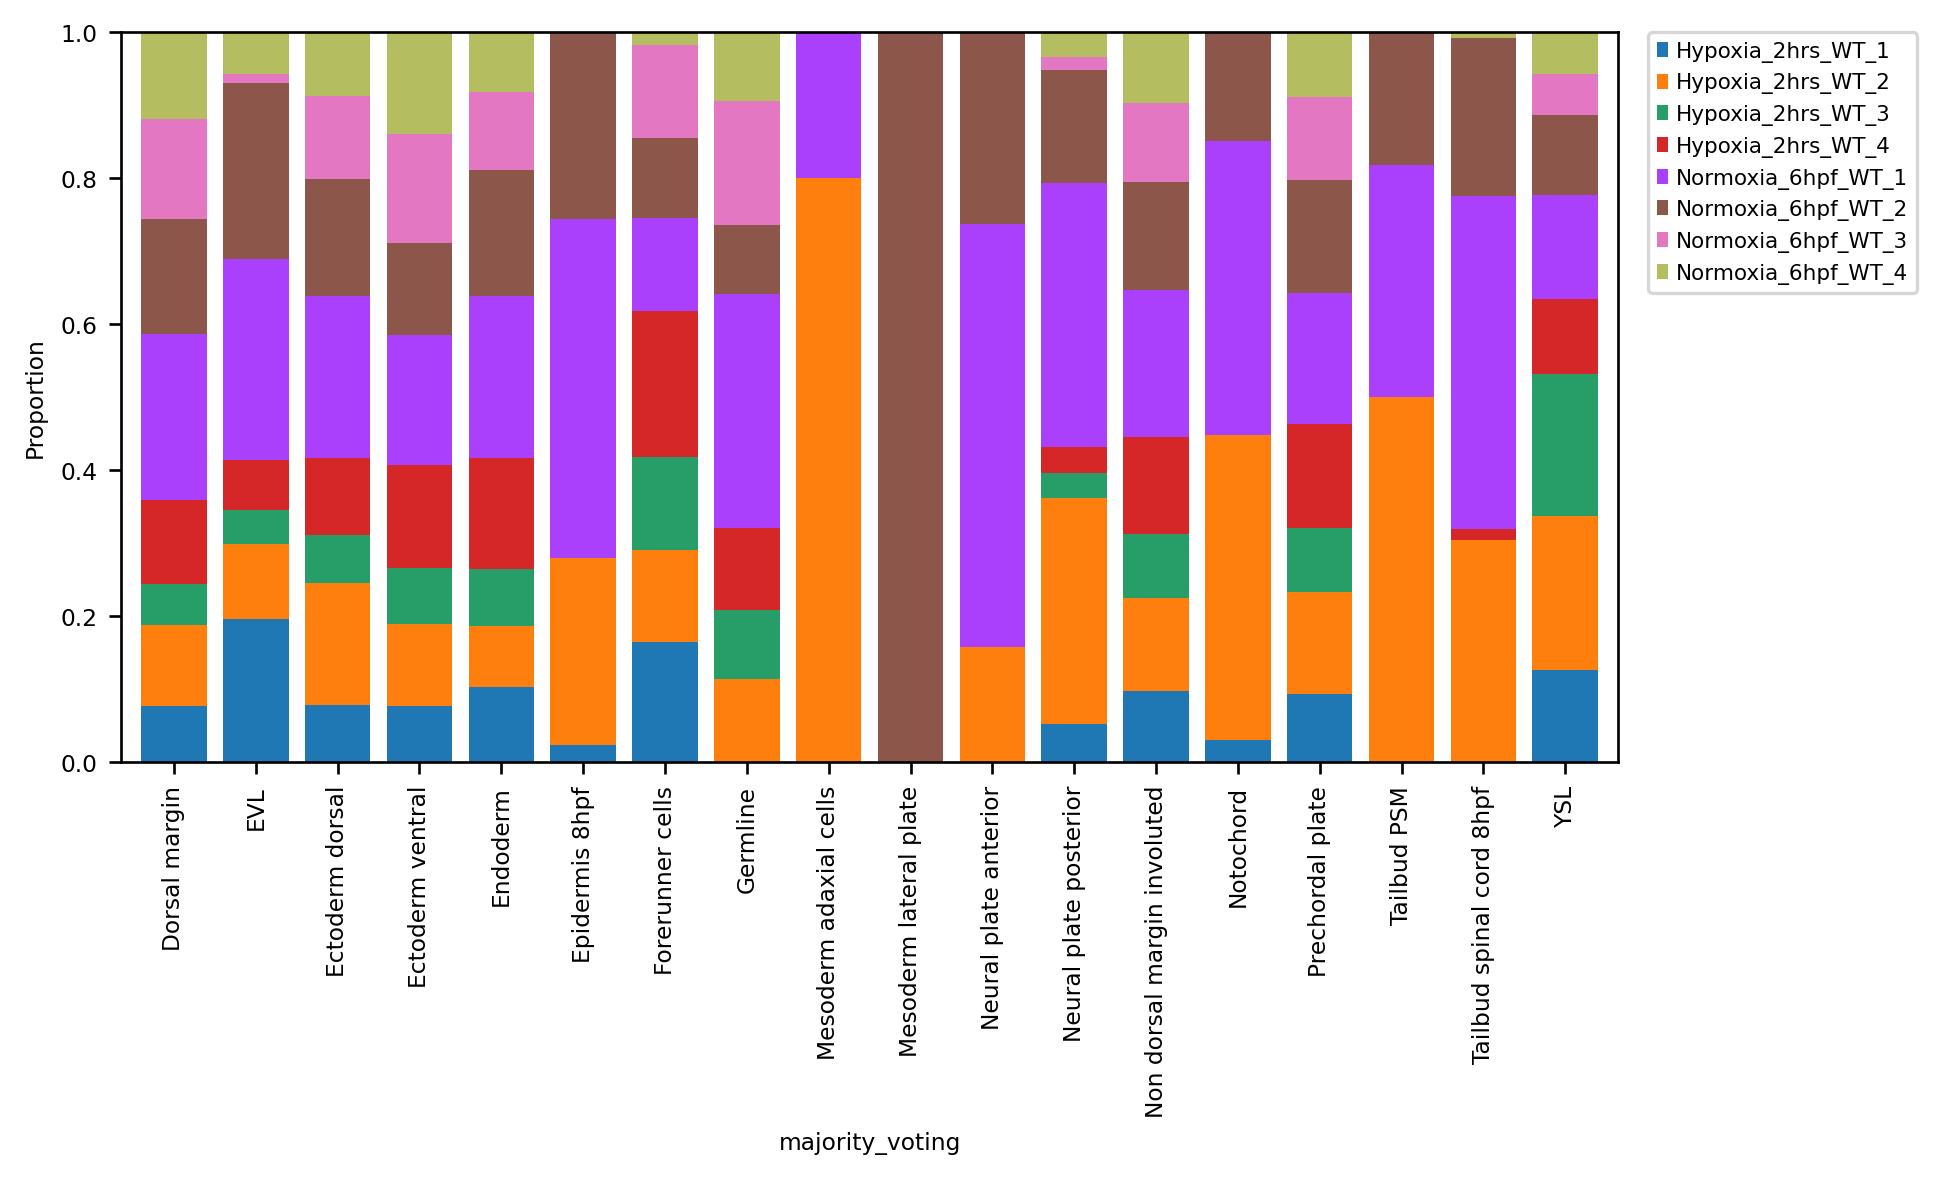

In [14]:
plot_stacked_barplot(adata.obs['majority_voting'], adata.obs['sample'], normalize='index', fig_width=8)

In [15]:
list(adata.obs['majority_voting'].unique())

['Dorsal margin',
 'Non dorsal margin involuted',
 'Ectoderm dorsal',
 'Ectoderm ventral',
 'YSL',
 'Prechordal plate',
 'Endoderm',
 'Forerunner cells',
 'EVL',
 'Neural plate posterior',
 'Epidermis 8hpf',
 'Notochord',
 'Tailbud PSM',
 'Tailbud spinal cord 8hpf',
 'Mesoderm adaxial cells',
 'Germline',
 'Neural plate anterior',
 'Mesoderm lateral plate']

In [16]:
# keep clusters that have enough replicates

enough = ['Dorsal margin',
 'Non dorsal margin involuted',
 'Ectoderm dorsal',
 'Ectoderm ventral',
 'YSL',
 'Prechordal plate',
 'Endoderm',
 'Forerunner cells',
 'EVL',
 'Neural plate posterior',
 'Epidermis 8hpf',
 'Notochord',
 'Tailbud PSM',
 'Tailbud spinal cord 8hpf',
 'Germline',
 'Neural plate anterior']
adata = adata[adata.obs['majority_voting'].isin(enough)].copy()

## Perform pyDESeq2 on each cluster

Reference Notebook: https://github.com/mousepixels/sanbomics_scripts/blob/main/pseudobulk_pyDeseq2.ipynb
Walkthrough: https://www.youtube.com/watch?v=Ee0PQUwVH8Q&ab_channel=Sanbomics


In [17]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

In [18]:
adata.obs['Condition'].unique()

['Hypoxia', 'Normoxia']
Categories (2, object): ['Hypoxia', 'Normoxia']

In [20]:
# Generate a pyDESeq2 results dataframe for each cluster
sample_use = 'sample'
cluster_use = 'majority_voting'

# Use a dictionary to store results
pyDESeq_results = {}

# Loop over all annotated clusters
clusters = list(np.unique(adata.obs[cluster_use]))
for cluster in clusters:
    print(cluster)
    adata_subset = adata[adata.obs[cluster_use] == cluster]

    # Generate a set of pseudo-bulk profiles as adata objects - one for each sample in this cluster
    pb_adata_list = []
    for sample in np.unique(adata_subset.obs[sample_use]):
        adata_subset_next = adata_subset[adata_subset.obs[sample_use] == sample]
        del adata_subset_next.X
        adata_subset_next.X = adata_subset_next.layers['raw_nolog']
        pb_adata_next = sc.AnnData(X=adata_subset_next.X.sum(axis=0), var=adata_subset_next.var[[]])
        pb_adata_next.obs_names = [sample]
        pb_adata_next.obs['Condition'] = adata_subset_next.obs['Condition'].iloc[0]
        pb_adata_list.append(pb_adata_next)

    # Concatenate the sample-level pseudo-bulk adatas
    pb_adata = sc.concat(pb_adata_list)

    # Run pyDESeq2
    dds = DeseqDataSet(counts=pd.DataFrame(pb_adata.X, columns=pb_adata.var_names), metadata=pb_adata.obs, design_factors='Condition')
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=('Condition', 'Normoxia', 'Hypoxia'))
    stat_res.summary()

    # Save sorted DEG list to csv for each cluster
    pyDESeq_results[cluster] = stat_res.results_df.sort_values('stat', ascending=False)
    # Modify the file name to include the cluster name
    cluster_file_name = '/content/drive/MyDrive/Chris/All/PydeseqCellTypist/' + f'Normoxia6hpfVsHypoxia2hrs_{cluster}.csv'
    pyDESeq_results[cluster].to_csv(cluster_file_name)

Dorsal margin


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.

Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.03 seconds.

Fitting dispersion trend curve...
... done in 0.50 seconds.

Fitting MAP dispersions...
... done in 2.35 seconds.

Fitting LFCs...
... done in 2.04 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.42 seconds.



Log2 fold change & Wald test p-value: Condition Normoxia vs Hypoxia
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
a1cf                9.640295       -1.141853  0.515410 -2.215428  0.026731   
a2ml                4.092084        0.267910  0.721914  0.371110  0.710555   
aaas               46.545035       -0.395371  0.274031 -1.442796  0.149078   
aacs               93.124628        0.471282  0.199834  2.358367  0.018356   
aadac               3.718398        0.665410  0.766589  0.868013  0.385387   
...                      ...             ...       ...       ...       ...   
echdc1              4.222734        0.011154  0.802364  0.013902  0.988908   
sipa1l2-1          28.679861        0.379506  0.424388  0.894244  0.371192   
eme2                2.457067       -0.126182  0.885344 -0.142524  0.886666   
si:ch211-122l14.5   0.227008       -1.961752  3.727764 -0.526254  0.598711   
taar10c-1           0.000000             NaN       NaN       NaN       NaN

...

Log2 fold change & Wald test p-value: Condition Normoxia vs Hypoxia
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
a1cf               1.868434       -3.044836  2.155121 -1.412838  0.157703   
a2ml               0.105759       -1.712434  2.288119 -0.748402  0.454217   
aaas               0.685938       -2.189911  1.859723 -1.177547  0.238977   
aacs               1.055647       -0.460136  1.822868 -0.252424  0.800713   
aadac              0.030464       -0.832269  2.550170 -0.326358  0.744153   
...                     ...             ...       ...       ...       ...   
echdc1             0.000000             NaN       NaN       NaN       NaN   
sipa1l2-1          0.124268       -1.541862  2.266530 -0.680275  0.496331   
eme2               0.000000             NaN       NaN       NaN       NaN   
si:ch211-122l14.5  0.000000             NaN       NaN       NaN       NaN   
taar10c-1          0.000000             NaN       NaN       NaN       NaN   

       

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  self._init_as_actual(
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:252: ImplicitModificationWarning: X should not be a np.

Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.13 seconds.

Fitting dispersion trend curve...
... done in 0.50 seconds.

Fitting MAP dispersions...
... done in 2.38 seconds.

Fitting LFCs...
... done in 2.08 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.49 seconds.



Log2 fold change & Wald test p-value: Condition Normoxia vs Hypoxia
                      baseMean  log2FoldChange     lfcSE      stat  \
a1cf               1179.474785       -0.554024  0.279287 -1.983710   
a2ml                725.031429        0.799632  0.307179  2.603149   
aaas                 47.350095       -0.855896  0.256345 -3.338849   
aacs                166.393064        1.067302  0.188172  5.671956   
aadac                15.681604       -1.243263  0.426203 -2.917067   
...                        ...             ...       ...       ...   
echdc1                4.799547        0.935951  0.699691  1.337663   
sipa1l2-1            25.904502       -0.318303  0.329465 -0.966120   
eme2                  2.120632       -1.367787  1.100894 -1.242433   
si:ch211-122l14.5     0.236793        1.376161  3.733708  0.368577   
taar10c-1             0.392634       -0.700837  2.554317 -0.274374   

                         pvalue          padj  
a1cf               4.728821e-02  1.147630e-